In [22]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import math
import matplotlib.pyplot as plt

# Task 1

1. Load the dataset using sklearn.


In [3]:
breast_cancer = load_breast_cancer()

2. Convert into DataFrame and explore structure.

In [4]:
df = pd.DataFrame(breast_cancer.data, columns = breast_cancer.feature_names)

In [5]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
df.shape

(569, 30)

In [7]:
df.dtypes

mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symmetry      

In [8]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


3. Check missing values and duplicates.

In [9]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

Setting the target variable

In [11]:
df["Diagnosis"] = breast_cancer.target

4. Apply feature scaling using StandardScaler and justify its importance.

Separating features and the target

In [12]:
X = df.drop("Diagnosis", axis = 1)
y = df["Diagnosis"]

In [13]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns = X.columns)

print(  )

Why feature scaling is important: the features in this Breast Cancer dataset have very different ranges. For instance, the mean area values initially were in the 100s range, while the mean smoothness feature has values close to 0.1. ML algorithms that depend on distances can be biased towards features with larger numerical values.

Standard Scaler helps standardize these features by subtracting its mean and dividing its standard deviation, which resultsin features with a mean of 0 and standard deviation 1. This helps ensure that all features contribute equally to the model and improves training speed and accuracy.

# Task 2

1. Split dataset into training and testing sets (80:20)

2. Repeat with 70:30 and 90:10 splits.

In [14]:
def evaluate_split(test_size): # creating a function to avoid repetitive splits
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = test_size, random_state = 42)

    knn = KNeighborsClassifier(n_neighbors = 5)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    return accuracy

3. Compare performance variations across splits.


In [15]:
splits = {
    "80:20": 0.20,
    "70:30": 0.30,
    "90:10": 0.10
}

for name, size in splits.items():
    accuracy = evaluate_split(size)
    print(f"{name} Split Accuracy: {accuracy:.4f}")

80:20 Split Accuracy: 0.9474
70:30 Split Accuracy: 0.9591
90:10 Split Accuracy: 0.9298


4. Analyze how dataset splitting affects model stability and generalization.

80:20 split - high accuracy, implying it can detect breast cancer cases effectively

70:30 split - highest accuracy, larger test set allows for a more comprehensive evaluation of its performance

90:10 split - lowest accuracy, implying that more training data does not guarantee better measured performance

# Task 3

3.1 Heuristic Method for K Selection

1. Compute initial K using heuristic rule (K =√n);where n = number of training samples

2. Use this value as a baseline K.


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2, random_state = 42) # sticking with the 80:20 split

In [19]:
# calculating heuristic K

n = len(X_train)

k = int(math.sqrt(n))

print("Training samples:", n)
print("Heuristic K:", k) # baseline K

Training samples: 455
Heuristic K: 21


3.2 Model Training

1. Train KNN classifier using heuristic K value.

In [20]:
knn = KNeighborsClassifier(n_neighbors = k)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9473684210526315


2. Experiment with nearby values of K (K ± 5).

In [21]:
k_values = range(k - 5, k + 6)

accuracies = []

for i in k_values:
    model = KNeighborsClassifier(n_neighbors = i)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    accuracies.append(accuracy)

    print(f"K = {i}, Accuracy = {accuracy:.4f}")

K = 16, Accuracy = 0.9561
K = 17, Accuracy = 0.9474
K = 18, Accuracy = 0.9561
K = 19, Accuracy = 0.9474
K = 20, Accuracy = 0.9474
K = 21, Accuracy = 0.9474
K = 22, Accuracy = 0.9474
K = 23, Accuracy = 0.9474
K = 24, Accuracy = 0.9474
K = 25, Accuracy = 0.9474
K = 26, Accuracy = 0.9474


3. Plot accuracy vs K values.

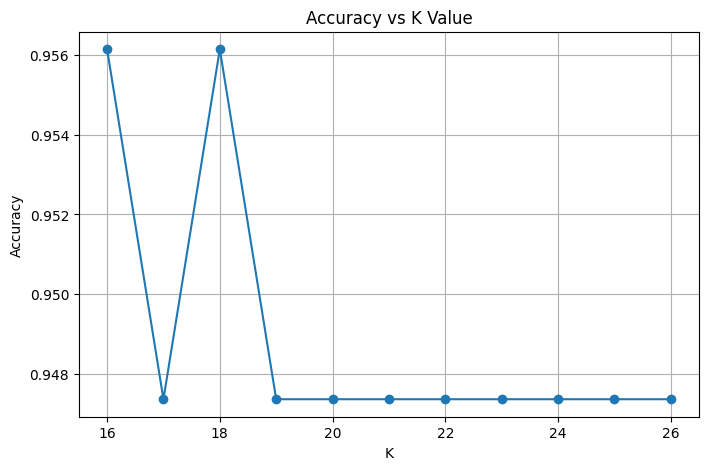

In [23]:
plt.figure(figsize = (8, 5))
plt.plot(k_values, accuracies, marker = "o")
plt.title("Accuracy vs K Value")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

4. Identify optimal K based on performance trend.

In [24]:
best_index = accuracies.index(max(accuracies))

best_k = list(k_values)[best_index]

print("Best K:", best_k)
print("Best Accuracy:", max(accuracies))

Best K: 16
Best Accuracy: 0.956140350877193


3.3 Distance Matrix and Decision Boundary Mapping 


1. Explain any two distance metrics used in KNN: Euclidean Distance and Manhattan Distance. Also mention when each distance metric is suitable.

Euclidean distance - calculates the straight-line distance between two points and is the default distance metric used in KNN. It performs well for continuous numerical data, specifically after feature scaling.

Manhattan Distance - calculates the sum of the absolute differences between feature values. It is less sensitive to outliers and is suitable when movement follows horizontal and vertical paths/when robustness to large deviations is desired.

2. Plot the decision boundary of the KNN classifier for different values of K, such as K = 1, K = 5, K = 10, and K = 20. Analyze how the decision boundary changes as K increase.